In [1]:
import os
import sys
import glob
import json
import pickle
import datetime
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.insert(1, '../utils')

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from mUtils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 11})

In [2]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

figureroot = "./results/system_02/lyapunov"
os.makedirs(figureroot, exist_ok=True)

In [3]:
load_dir = "../system_02/results/lyapunov/"
load_str = datetime.datetime(2024, 3, 6)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 50


In [4]:
iE = -0.25 / params['gamma'] - params['i_e2']
kMin = -1; kMax = 1; kSteps = 10
kVals = kMin + np.arange(0, kSteps) / kSteps * (kMax - kMin)

seMin = 2.5; seMax = 16.5; seSteps = 20
seVals = seMin + np.arange(0, seSteps) / (seSteps - 1) * (seMax - seMin)

siMin = 2.5; siMax = 16.5; siSteps = 20
siVals = siMin + np.arange(0, siSteps) / (siSteps - 1) * (siMax - siMin)

In [5]:
_temp = []
_sortpaths = []

for path_ in file_paths:
    if f"_{iE + params['i_e2']:.3f}" not in path_:
        continue

    Basename = os.path.basename(path_).split('.pkl')[0]
    K = float(Basename.split('_K_')[-1].split('_ie_')[0])
    _temp.append(K)
    _sortpaths.append(path_)

_temp = np.array(_temp)
Ksort = np.argsort(_temp)

_sortpaths = np.array(_sortpaths)
_sortpaths = _sortpaths[Ksort]

In [6]:
Lyap = np.zeros((kSteps, 4))
sigE = np.zeros((kSteps, 4))
sigI = np.zeros((kSteps, 4))

for nf, path_ in enumerate(_sortpaths):

    lyap_results = pickle.load(open(path_, 'rb'))

    lyap_results = lyap_results['n1_mean']
    if len(lyap_results[lyap_results != -np.inf].flatten()) == 0:
        minValue = -15
    else:
        minValue = min(lyap_results[lyap_results != -np.inf])
    lyap_results[lyap_results == -np.inf] = minValue
    
    sigE[nf, 0] = seVals[0]; sigI[nf, 0] = siVals[2]; Lyap[nf, 0] = lyap_results[0, 2]
    sigE[nf, 1] = seVals[0]; sigI[nf, 1] = siVals[-1]; Lyap[nf, 1] = lyap_results[0, -1]
    sigE[nf, 2] = seVals[10]; sigI[nf, 2] = siVals[2]; Lyap[nf, 2] = lyap_results[10, 2]
    sigE[nf, 3] = seVals[10]; sigI[nf, 3] = siVals[-1]; Lyap[nf, 3] = lyap_results[10, -1]

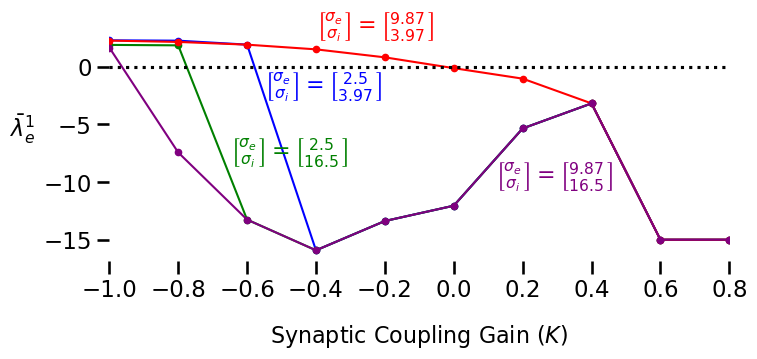

In [7]:
colors= plt.get_cmap('jet')
colorIter = iter(colors(np.linspace(0.3, 1, 4)))

plt.figure(figsize=(8, 3))

plt.plot(kVals, Lyap[:, 0], '.-', color = 'b', linewidth=1.5)
plt.text(-0.55, -2.2, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{2.5}{3.97}$', color = 'b',  fontsize=16)

plt.plot(kVals, Lyap[:, 1], '.-', color = 'g', linewidth=1.5)
plt.text(-0.65, -8, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = 'g',  fontsize=16)

plt.plot(kVals, Lyap[:, 2], '.-', color = 'r', linewidth=1.5)
plt.text(-0.4, 3, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{9.87}{3.97}$', color = 'r',  fontsize=16)

plt.plot(kVals, Lyap[:, 3], '.-', color = 'purple', linewidth=1.5)
plt.text(0.12, -10, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} = \genfrac{[}{]}{0}{1}{9.87}{16.5}$', color = 'purple',  fontsize=16)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\bar{\lambda}^1_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)
plt.xlim(kMin, max(kVals))
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_K.png"), dpi=300, bbox_inches='tight')
    

In [8]:
K = 0.0

seMin = 2.5; seMax = 16.5; seSteps = 20
seVals = seMin + np.arange(0, seSteps) / (seSteps - 1) * (seMax - seMin)

siMin = 2.5; siMax = 16.5; siSteps = 20
siVals = siMin + np.arange(0, siSteps) / (siSteps - 1) * (siMax - siMin)

In [9]:
_temp = []
_sortpaths = []

for path_ in file_paths:
    if f"K_{K:.2f}" not in path_:
        continue
    Basename = os.path.basename(path_).split('.pkl')[0]
    I = float(Basename.split('_ie_')[-1])
    _temp.append(I)
    _sortpaths.append(path_)

_temp = np.array(_temp)
Isort = np.argsort(_temp)

_sortpaths = np.array(_sortpaths)
_sortpaths = _sortpaths[Isort]
iVals = _temp[Isort]
iVals -= params['i_e2']

In [10]:
Lyap = np.zeros((len(_temp), 4))
sigE = np.zeros((len(_temp), 4))
sigI = np.zeros((len(_temp), 4))

for nf, path_ in enumerate(_sortpaths):

    lyap_results = pickle.load(open(path_, 'rb'))

    lyap_results = lyap_results['n1_mean']

    if len(lyap_results[lyap_results != -np.inf].flatten()) == 0:
        minValue = -15
    else:
        minValue = min(lyap_results[lyap_results != -np.inf])

    lyap_results[lyap_results == -np.inf] = minValue
    
    sigE[nf, 0] = seVals[0]; sigI[nf, 0] = siVals[2]; Lyap[nf, 0] = lyap_results[0, 2]
    sigE[nf, 1] = seVals[0]; sigI[nf, 1] = siVals[-1]; Lyap[nf, 1] = lyap_results[0, -1]
    sigE[nf, 2] = seVals[10]; sigI[nf, 2] = siVals[2]; Lyap[nf, 2] = lyap_results[10, 2]
    sigE[nf, 3] = seVals[10]; sigI[nf, 3] = siVals[-1]; Lyap[nf, 3] = lyap_results[10, -1]

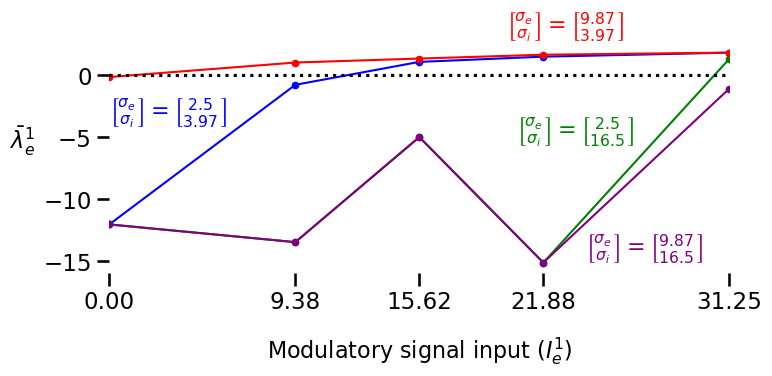

In [11]:
colors= plt.get_cmap('jet')
colorIter = iter(colors(np.linspace(0.3, 1, 4)))

plt.figure(figsize=(8, 3))

plt.plot(iVals, Lyap[:, 0], '.-', color = 'b', linewidth=1.5)
plt.text(0, -3.5, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{2.5}{3.97}$', color = 'b',  fontsize=16)

plt.plot(iVals, Lyap[:, 1], '.-', color = 'g', linewidth=1.5)
plt.text(20.5, -5, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = 'g',  fontsize=16)

plt.plot(iVals, Lyap[:, 2], '.-', color = 'r', linewidth=1.5)
plt.text(20, 3.5, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{9.87}{3.97}$', color = 'r',  fontsize=16)

plt.plot(iVals, Lyap[:, 3], '.-', color = 'purple', linewidth=1.5)
plt.text(24, -14.5, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} = \genfrac{[}{]}{0}{1}{9.87}{16.5}$', color = 'purple',  fontsize=16)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\bar{\lambda}^1_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)
plt.xlim(min(iVals), max(iVals))
plt.xticks(iVals)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
# plt.savefig(os.path.join(figureroot, f"K_{K:.2f}_Imod.png"), dpi=300, bbox_inches='tight')
    

#### State transition boundary detection

In [12]:
# setting the variables
k_values = np.arange(-1, 1, 0.2)
iPert = [0.  , 0.15, 0.25, 0.35, 0.5] 

sige_min = 2.5; sige_max = 16.5; sige_steps = 20
sigi_min = 2.5; sigi_max = 16.5; sigi_steps = 20

eval_sigma_e = sige_min + np.arange(0, sige_steps) / (sige_steps - 1) * (sige_max - sige_min)
eval_sigma_i = sigi_min + np.arange(0, sigi_steps) / (sigi_steps - 1) * (sigi_max - sigi_min)

In [17]:
%%capture
save_str = datetime.datetime(2024, 3, 6)
results_dict = os.path.join('../system_02/results/lyapunov/', f"exp-{save_str.year}-{save_str.month}-{save_str.day}")

for nI, I in enumerate(iPert):
    file_paths = glob.glob(os.path.join(results_dict, f"*_ie_{I / params['gamma'] + params['i_e2']:.3f}.pkl"))
    num_files = len(file_paths)

    K_vals = []

    if num_files == 0:
        print('no files found!')

    else:
        for nf, path in enumerate(file_paths):
            basename = os.path.basename(path).split('.pkl')[0]
            K = float(basename.split('K_')[-1].split('_ie')[0])

            if K == -0.00:
                K = 0.0
            K_vals.append(K)
        
        K_vals = np.array(K_vals)

        order_ind = np.argsort(K_vals)
        K_vals = K_vals[order_ind]
        file_paths = np.array(file_paths)[order_ind]

        colors= plt.get_cmap('Reds')
        colorIter = iter(colors(np.linspace(0.3, 1, len(K_vals))))

        last_response = None
        ifPlot = True
        plt.figure(figsize=(10,8))
            
        for nf, path in enumerate(file_paths):
            if K_vals[nf] == 0.2:
                lyap_results = pickle.load(open(path, 'rb'))

                orig_response = lyapunov_threshold(lyap_results['n1_mean'], 0.001)

                sige_arr, sigi_arr, response_map = lyapunov_upsample(
                                                                    orig_response=orig_response, 
                                                                    eval_arrx=eval_sigma_i, 
                                                                    eval_arry=eval_sigma_e, 
                                                                    y_min = sige_min, y_max = len(eval_sigma_e), 
                                                                    x_min = sigi_min, x_max = len(eval_sigma_i), 
                                                                    sigma_x = 25, sigma_y = 25,  
                                                                    resolution = 500
                                                                )
                heatmap = plt.pcolormesh(sigi_arr, sige_arr, response_map, cmap=ListedColormap(['lightcyan', 'mistyrose']))
                cbar = plt.colorbar(heatmap)

                cbar.ax.get_yaxis().set_ticks([])
                cbar.ax.text(0.5, .5 , r"Unstable", rotation=270, ha='center', va='center', fontsize=15)
                cbar.ax.text(0.5, -0.5 , r"Stable", rotation=270, ha='center', va='center', fontsize=15)

        for nf, path in enumerate(file_paths):
            basename = os.path.basename(path).split('.pkl')[0]
            I = float(basename.split('ie_')[-1])
            color = next(colorIter)
            
            lyap_results = pickle.load(open(path, 'rb'))

            orig_response = lyapunov_threshold(lyap_results['n1_mean'], 0.001)

            sige_arr, sigi_arr, response_map = lyapunov_upsample(
                                                                    orig_response=orig_response, 
                                                                    eval_arrx=eval_sigma_i, 
                                                                    eval_arry=eval_sigma_e, 
                                                                    y_min = sige_min, y_max = len(eval_sigma_e), 
                                                                    x_min = sigi_min, x_max = len(eval_sigma_i), 
                                                                    sigma_x = 25, sigma_y = 25,  
                                                                    resolution = 500
                                                                )
            
            edge_boundary, sigi_edges, sige_edges = boundary_detection(response_map, sige_arr, sigi_arr)

                
            if not edge_boundary:
                continue

            plt.scatter(sigi_edges, sige_edges, marker='.', s = 16, c = color,  label = f"K = {K_vals[nf]:.2f}")
        
        plt.xlabel(r"Inhibitory heterogeneity $(\sigma_i)$"); plt.ylabel(r"Excitatory heterogeneity $(\sigma_e)$")
        plt.xticks(np.linspace(2.5, 16.5, 10), rotation = 90); plt.yticks(np.linspace(2.5, 16.5, 10))
        plt.xlim(2.5, 16.5); plt.ylim(2.5, 16.5)
        # plt.title(r"$I^1_e = $" + f"{I - params['i_e2']:.3f}mV")
        plt.legend(loc = 'lower center', bbox_to_anchor=(0.5, -0.4), edgecolor="white", ncols=4, markerscale=5, fontsize=16)
        plt.savefig(os.path.join(figureroot, f"boundarydetection_modulation_Imod_{I - params['i_e2']:.3f}mV.png"), dpi = 300, bbox_inches='tight')
        plt.show()